## 4. a Sentiment Analysis (VADER)

--- Phase 4a: Sentiment Analysis (VADER) ---
Successfully loaded 'MASTER_feature_engineered.csv'. Shape: (100875, 80)
Running VADER sentiment analysis... (This may take a minute)
...Sentiment analysis complete.
Saved 'MASTER_with_sentiment.csv' for the next phase (BERTopic).

--- Sentiment Analysis Results ---
count    100875.000000
mean          0.239925
std           0.541516
min          -0.999000
25%          -0.060200
50%           0.340000
75%           0.718400
max           0.999500
Name: sentiment_compound, dtype: float64

Generated 'plot_6_sentiment_distribution.png'


C:\Users\chauh\AppData\Local\Temp\ipykernel_23652\267690593.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Generated 'plot_7_sentiment_by_language.png'


C:\Users\chauh\AppData\Local\Temp\ipykernel_23652\267690593.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Generated 'plot_8_sentiment_by_product.png'


C:\Users\chauh\AppData\Local\Temp\ipykernel_23652\267690593.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Generated 'plot_9_sentiment_by_narrative.png'

--- Phase 4a Complete ---


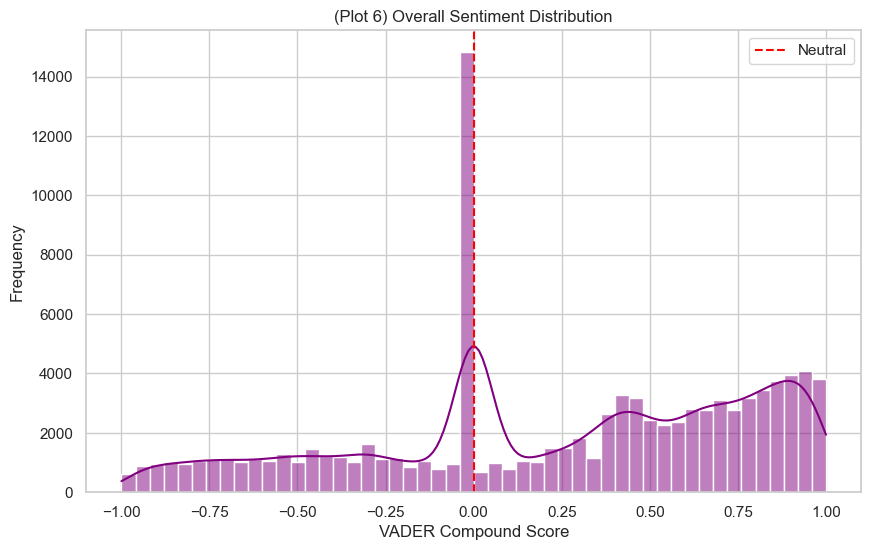

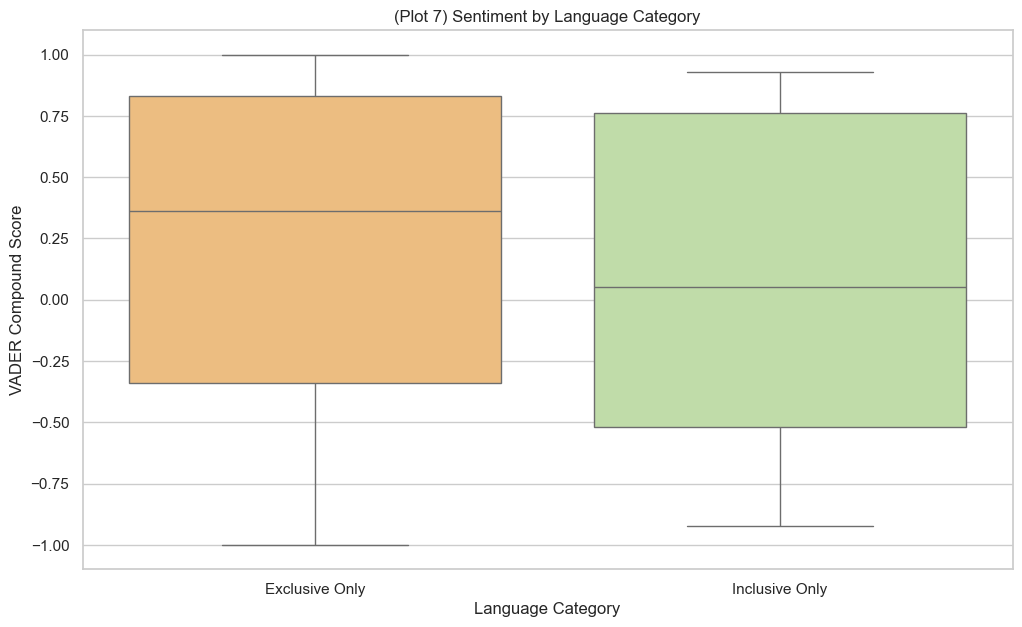

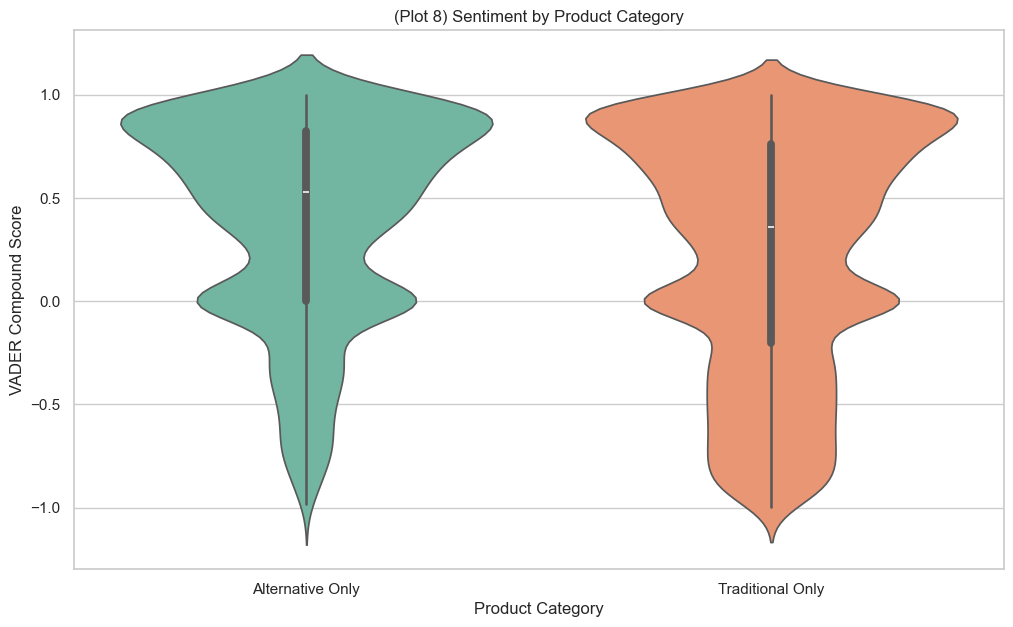

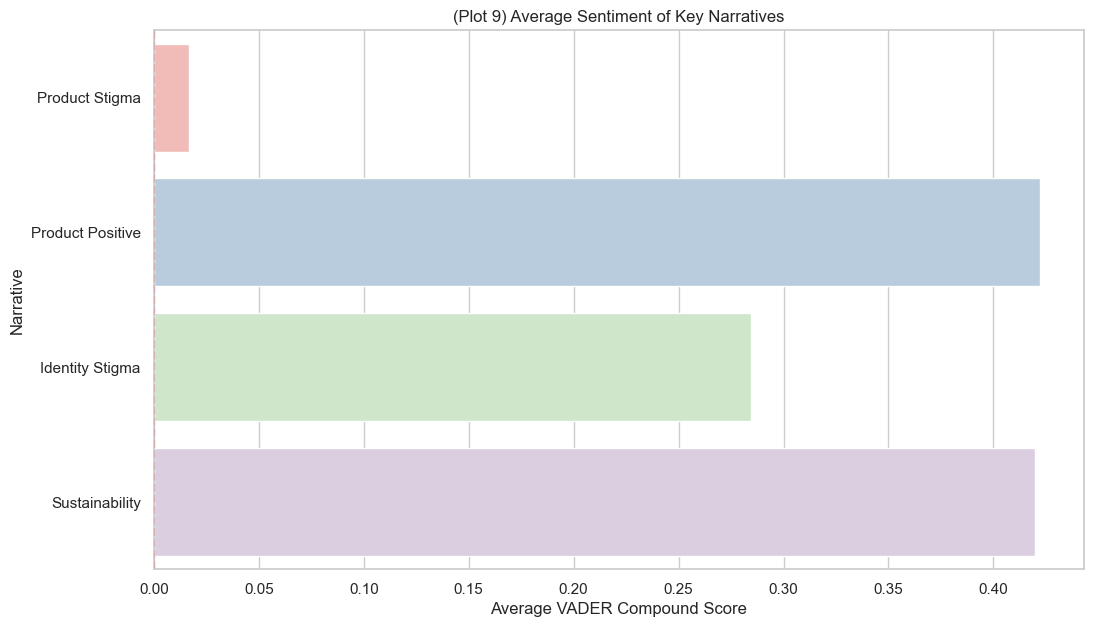

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print("--- Phase 4a: Sentiment Analysis (VADER) ---")

try:
    # 1. Load the feature-engineered dataset from Phase 2/3
    df = pd.read_csv("MASTER_feature_engineered.csv")
    print(f"Successfully loaded 'MASTER_feature_engineered.csv'. Shape: {df.shape}")

    # 2. Initialize VADER
    analyzer = SentimentIntensityAnalyzer()

    # 3. Define a function to get sentiment
    def get_sentiment(text):
        # VADER works best on raw text. 
        # Ensure text is a string
        if not isinstance(text, str):
            text = str(text)
        
        # Get sentiment scores
        scores = analyzer.polarity_scores(text)
        
        # We are most interested in the 'compound' score
        return scores['compound']

    print("Running VADER sentiment analysis... (This may take a minute)")
    
    # 4. Apply VADER to our text column
    # We use 'text_to_analyze' as it is our primary text
    df['sentiment_compound'] = df['text_to_analyze'].apply(get_sentiment)
    
    print("...Sentiment analysis complete.")

    # 5. Save the new dataframe with sentiment scores
    df.to_csv('MASTER_with_sentiment.csv', index=False)
    print("Saved 'MASTER_with_sentiment.csv' for the next phase (BERTopic).")

    # --- 6. Analysis & Visualization of Sentiment ---
    print("\n--- Sentiment Analysis Results ---")
    print(df['sentiment_compound'].describe())

    sns.set_theme(style="whitegrid")

    # Plot 6: Overall Sentiment Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df['sentiment_compound'], bins=50, kde=True, color='purple')
    plt.title('(Plot 6) Overall Sentiment Distribution')
    plt.xlabel('VADER Compound Score')
    plt.ylabel('Frequency')
    plt.axvline(0, color='red', linestyle='--', label='Neutral')
    plt.legend()
    plt.savefig('plot_6_sentiment_distribution.png')
    print("\nGenerated 'plot_6_sentiment_distribution.png'")

    # Plot 7: Sentiment by Language Category
    # We'll focus on the main ones
    lang_filter = df['language_category'].isin(['Inclusive Only', 'Exclusive Only'])
    
    plt.figure(figsize=(12, 7))
    sns.boxplot(
        data=df[lang_filter], 
        x='language_category', 
        y='sentiment_compound',
        palette='Spectral'
    )
    plt.title('(Plot 7) Sentiment by Language Category')
    plt.xlabel('Language Category')
    plt.ylabel('VADER Compound Score')
    plt.savefig('plot_7_sentiment_by_language.png')
    print("Generated 'plot_7_sentiment_by_language.png'")

    # Plot 8: Sentiment by Product Category
    prod_filter = df['product_category'].isin(['Traditional Only', 'Alternative Only'])
    
    plt.figure(figsize=(12, 7))
    sns.violinplot(
        data=df[prod_filter], 
        x='product_category', 
        y='sentiment_compound',
        palette='Set2'
    )
    plt.title('(Plot 8) Sentiment by Product Category')
    plt.xlabel('Product Category')
    plt.ylabel('VADER Compound Score')
    plt.savefig('plot_8_sentiment_by_product.png')
    print("Generated 'plot_8_sentiment_by_product.png'")

    # Plot 9: Sentiment of Narratives (Sanity Check)
    # This is more complex, let's create a "narrative_sentiment" df
    narr_sent = []
    narr_sent.append({'narrative': 'Product Stigma', 'sentiment': df[df['mentions_product_stigma'] == 1]['sentiment_compound'].mean()})
    narr_sent.append({'narrative': 'Product Positive', 'sentiment': df[df['mentions_product_positive'] == 1]['sentiment_compound'].mean()})
    narr_sent.append({'narrative': 'Identity Stigma', 'sentiment': df[df['mentions_identity_stigma'] == 1]['sentiment_compound'].mean()})
    narr_sent.append({'narrative': 'Sustainability', 'sentiment': df[df['mentions_sustainability'] == 1]['sentiment_compound'].mean()})
    
    df_narr_sent = pd.DataFrame(narr_sent)
    
    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=df_narr_sent, 
        x='sentiment', 
        y='narrative', 
        palette='Pastel1'
    )
    plt.title('(Plot 9) Average Sentiment of Key Narratives')
    plt.xlabel('Average VADER Compound Score')
    plt.ylabel('Narrative')
    plt.axvline(0, color='red', linestyle='--')
    plt.savefig('plot_9_sentiment_by_narrative.png')
    print("Generated 'plot_9_sentiment_by_narrative.png'")

    print("\n--- Phase 4a Complete ---")

except FileNotFoundError:
    print("Error: Could not find 'MASTER_feature_engineered.csv'.")
    print("Please make sure the output from Phase 2/3 is in the same directory.")
except Exception as e:
    print(f"An error occurred: {e}")

## Phase 4b: BERTopic Modeling (The "BERT" Step)

In [10]:
import sys
!"{sys.executable}" -m pip install bertopic
!"{sys.executable}" -m pip install "bertopic[visualization]"
!"{sys.executable}" -m pip install sentence-transformers


  Using cached bertopic-0.17.3-py3-none-any.whl.metadata (24 kB)
  Using cached umap_learn-0.5.9.post2-py3-none-any.whl.metadata (25 kB)
  Using cached sentence_transformers-5.1.2-py3-none-any.whl.metadata (16 kB)
  Using cached transformers-4.57.1-py3-none-any.whl.metadata (43 kB)
  Using cached pynndescent-0.5.13-py3-none-any.whl.metadata (6.8 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-win_amd64.whl.metadata (5.0 kB)
  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.1-cp39-abi3-win_amd64.whl.metadata (6.9 kB)
  Using cached safetensors-0.6.2-cp38-abi3-win_amd64.whl.metadata (4.1 kB)
Using cached bertopic-0.17.3-py3-none-any.whl (153 kB)
   ---------------------------------------- 0.0/732.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/732.2 kB ? eta -:--:--
   -------------- ------------------------- 262.1/732.2 kB ? eta -:--:--
   -------------- ------------------------- 262.1/732.2 kB ? eta -:--:--
   ----------

In [1]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import warnings

# Suppress all warnings for cleaner output
warnings.filterwarnings("ignore")

print("--- Phase 4b: Comparative BERTopic Modeling ---")

try:
    # 1. Load the dataset with sentiment
    df = pd.read_csv("MASTER_with_sentiment.csv")
    print(f"Successfully loaded 'MASTER_with_sentiment.csv'. Shape: {df.shape}")

    # 2. Prepare the corpora
    # We need to make sure we're using string data
    df['text_to_analyze'] = df['text_to_analyze'].astype(str)

    # Corpus 1: Identity-Focused (r/ftm)
    corpus_ftm = df[df['subreddit'] == 'ftm']['text_to_analyze'].tolist()
    print(f"Created 'r/ftm' corpus with {len(corpus_ftm)} documents.")

    # Corpus 2: Product-Focused (r/menstrualcups)
    corpus_cups = df[df['subreddit'] == 'menstrualcups']['text_to_analyze'].tolist()
    print(f"Created 'r/menstrualcups' corpus with {len(corpus_cups)} documents.")
    # Corpus 3: General Period Talk (r/periods)
    corpus_periods = df[df['subreddit'] == 'periods']['text_to_analyze'].tolist()
    print(f"Created 'r/periods' corpus with {len(corpus_periods)} documents.")
    # 3. Define our modeling function
    def run_bertopic(corpus, corpus_name):
        print(f"\n--- Starting BERTopic for {corpus_name} ---")
        
        # For large corpora, we can sample, but let's try the full one
        # If this is too slow, we can add: corpus = sample(corpus, 5000)
        
        # Load a high-quality embedding model
        embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
        
        # Initialize BERTopic
        # We use 'auto' for n_neighbors, which works well
        # nr_topics='auto' will find the optimal number of topics
        topic_model = BERTopic(
            embedding_model=embedding_model,
            nr_topics="auto",
            verbose=True
        )

        print(f"Fitting BERTopic model for {corpus_name}... (This will take a long time)")
        topics, probs = topic_model.fit_transform(corpus)

        print("...Fit complete.")
        
        # 4. Analyze results
        print(f"\n--- Top Topics for {corpus_name} ---")
        # Get the top 15 topics. Topic -1 is the "outlier" topic (noise)
        top_topics = topic_model.get_topic_info().head(15)
        print(top_topics)
        
        # Let's see the keywords for the top 5 *real* topics
        print(f"\n--- Top 5 Topic Keywords for {corpus_name} ---")
        for topic_id in top_topics[top_topics['Topic'] != -1]['Topic'].head(5):
            topic_words = topic_model.get_topic(topic_id)
            print(f"Topic {topic_id}: {[word[0] for word in topic_words]}")

        # 5. Visualize
        print("Generating visualizations...")
        
        # Plot 10: Topic Hierarchy
        # This shows how topics are related
        try:
            fig_hierarchy = topic_model.visualize_hierarchy()
            fig_hierarchy.write_html(f"plot_10_hierarchy_{corpus_name}.html")
            print(f"Saved 'plot_10_hierarchy_{corpus_name}.html'")
        except Exception as e:
            print(f"Could not generate hierarchy plot: {e}")

        # Plot 11: Topic-Word Score Barcharts
        try:
            fig_barchart = topic_model.visualize_barchart(top_n_topics=10)
            fig_barchart.write_html(f"plot_11_barcharts_{corpus_name}.html")
            print(f"Saved 'plot_11_barcharts_{corpus_name}.html'")
        except Exception as e:
            print(f"Could not generate barchart plot: {e}")

        print(f"--- BERTopic for {corpus_name} COMPLETE ---")

    # --- Run the models ---
    run_bertopic(corpus_ftm, "ftm")
    run_bertopic(corpus_cups, "menstrualcups")
    run_bertopic(corpus_periods,"periods")

    print("\n--- Phase 4b Complete ---")

except FileNotFoundError:
    print("Error: Could not find 'MASTER_with_sentiment.csv'.")
    print("Please make sure the output from Phase 4a is in the same directory.")
except ImportError:
    print("\n--- ERROR ---")
    print("BERTopic or sentence-transformers not installed.")
    print("Please run: pip install bertopic bertopic[visualization] sentence-transformers")
except Exception as e:
    print(f"An error occurred: {e}")

C:\Users\chauh\anaconda3\Scripts\New folder\envs\notebook\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Phase 4b: Comparative BERTopic Modeling ---
Successfully loaded 'MASTER_with_sentiment.csv'. Shape: (100875, 81)
Created 'r/ftm' corpus with 13512 documents.
Created 'r/menstrualcups' corpus with 11488 documents.
Created 'r/periods' corpus with 0 documents.

--- Starting BERTopic for ftm ---


2025-11-14 18:26:11,090 - BERTopic - Embedding - Transforming documents to embeddings.


Fitting BERTopic model for ftm... (This will take a long time)


Batches: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 423/423 [05:39<00:00,  1.25it/s]
2025-11-14 18:31:51,237 - BERTopic - Embedding - Completed ✓
2025-11-14 18:31:51,254 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-14 18:33:00,957 - BERTopic - Dimensionality - Completed ✓
2025-11-14 18:33:00,972 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-14 18:33:01,971 - BERTopic - Cluster - Completed ✓
2025-11-14 18:33:01,972 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-11-14 18:33:03,268 - BERTopic - Representation - Completed ✓
2025-11-14 18:33:03,275 - BERTopic - Topic reduction - Reducing number of topics
2025-11-14 18:33:03,359 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-14 18:33:04,453 - BERTopic - Representation - Completed ✓
2025-11-14 18:33:04,462 - BERTopic - Topic reduction - 

...Fit complete.

--- Top Topics for ftm ---
    Topic  Count                                       Name  \
0      -1   5721                            -1_it_to_and_of   
1       0   1257            0_pads_boxers_tampons_underwear   
2       1    872  1_control_birth_progesterone_testosterone   
3       2    776                    2_people_trans_women_as   
4       3    342                  3_thank_thanks_hope_sorry   
5       4    292                   4_bathroom_toilet_men_in   
6       5    195               5_bag_backpack_pockets_black   
7       6    168              6_iud_mirena_copper_insertion   
8       7    157                    7_rules_report_wiki_ftm   
9       8    141           8_atrophy_cream_dryness_estrogen   
10      9    138                  9_dose_levels_high_dosage   
11     10    133              10_hair_beard_facial_mustache   
12     11    112               11_dysphoria_it_dysphoric_me   
13     12    100                   12_videos_asmr_thanks_ll   
14     13 

2025-11-14 18:33:15,045 - BERTopic - Embedding - Transforming documents to embeddings.


Fitting BERTopic model for menstrualcups... (This will take a long time)


Batches: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 359/359 [04:11<00:00,  1.43it/s]
2025-11-14 18:37:27,579 - BERTopic - Embedding - Completed ✓
2025-11-14 18:37:27,586 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-14 18:37:35,438 - BERTopic - Dimensionality - Completed ✓
2025-11-14 18:37:35,457 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-14 18:37:36,496 - BERTopic - Cluster - Completed ✓
2025-11-14 18:37:36,497 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-11-14 18:37:37,704 - BERTopic - Representation - Completed ✓
2025-11-14 18:37:37,708 - BERTopic - Topic reduction - Reducing number of topics
2025-11-14 18:37:37,808 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-14 18:37:38,468 - BERTopic - Representation - Completed ✓
2025-11-14 18:37:38,475 - BERTopic - Topic reduction - 

...Fit complete.

--- Top Topics for menstrualcups ---
    Topic  Count                            Name  \
0      -1   5650                -1_the_it_to_and   
1       0   4340                 0_the_it_to_and   
2       1    148        1_thank_you_thanks_happy   
3       2     99  2_thanks_thank_welcome_helpful   
4       3     85       3_code_referral_dm_please   
5       4     84        4_sorry_glad_happened_re   
6       5     52          5_thanks_thank_tip_try   
7       6     51     6_jdv58456_club_thinx_https   
8       7     50  7_lube_water_based_lubrication   
9       8     49             8_same_me_too_ditto   
10      9     47    9_down_squatting_squat_relax   
11     10     37       10_size_sizes_bigger_fits   
12     11     33     11_blood_red_slugs_residual   
13     12     33       12_her_she_sister_nirvana   
14     13     33         13_one_two_heavier_days   

                                       Representation  \
0     [the, it, to, and, my, cup, you, that, of, for]  

--- Phase 4b (FINAL): Comparative BERTopic Modeling ---
Running for r/ftm, r/menstrualcups, AND r/Periods. Finding Top 20 topics.
Loading original CSV files...
...Original files loaded.
Creating 'text_to_analyze' column...
Created master DataFrame with 100875 documents.
Created 'r/ftm' corpus with 13512 documents.
Created 'r/menstrualcups' corpus with 11488 documents.
Created 'r/Periods' corpus with 22380 documents.

--- Starting BERTopic for ftm ---


2025-11-14 18:55:18,726 - BERTopic - Embedding - Transforming documents to embeddings.


Fitting BERTopic model for ftm... (This will take a long time)


Batches: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 423/423 [05:24<00:00,  1.30it/s]
2025-11-14 19:00:44,092 - BERTopic - Embedding - Completed ✓
2025-11-14 19:00:44,092 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-14 19:00:49,423 - BERTopic - Dimensionality - Completed ✓
2025-11-14 19:00:49,437 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-14 19:00:50,335 - BERTopic - Cluster - Completed ✓
2025-11-14 19:00:50,335 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-11-14 19:00:51,418 - BERTopic - Representation - Completed ✓
2025-11-14 19:00:51,418 - BERTopic - Topic reduction - Reducing number of topics
2025-11-14 19:00:51,518 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-14 19:00:52,234 - BERTopic - Representation - Completed ✓
2025-11-14 19:00:52,250 - BERTopic - Topic reduction - 

...Fit complete.

--- Top 20 Topics for ftm ---
                                        Name  Count
1                         0_it_my_on_control   1959
2             1_pads_underwear_boxers_briefs   1090
3                      2_trans_men_people_as    633
4                  3_thank_hope_thanks_sorry    320
5                     4_bathroom_in_room_men    277
6               5_bag_backpack_black_pockets    191
7                6_hair_beard_shaving_facial    171
8                    7_rules_report_wiki_ftm    159
9                  8_afab_amab_female_people    133
10          9_atrophy_cream_dryness_estrogen    133
11                      10_pap_smear_she_you    115
12                  11_thanks_videos_asmr_ll    110
13            12_test_pregnancy_pregnant_you     98
14              13_dysphoria_it_dysphoric_me     94
15           14_packaging_neutral_brand_blue     93
16           15_thank_thanks_helpful_welcome     87
17                   16_shark_week_call_moon     76
18              

...

...Fit complete.

--- Top 20 Topics for menstrualcups ---
                                Name  Count
1                   0_the_to_and_cup   2470
2              1_thank_thanks_you_ll    410
3             2_soap_boil_wash_water    182
4              3_stall_wipes_wipe_in    148
5         4_saalt_soft_regular_small    125
6                 5_mom_she_her_your    101
7         6_sorry_glad_happened_feel     91
8       7_hymen_virginity_her_virgin     83
9            8_amazon_00_price_store     75
10    9_doctor_adrenaline_urgent_you     73
11  10_sink_toilet_bathroom_disabled     72
12      11_down_squatting_poop_squat     71
13              12_pot_her_she_gross     66
14             13_bv_smell_after_hsv     60
15        14_smell_smells_smelled_my     57
16          15_fold_punch_folds_open     56
17  16_peroxide_hydrogen_stains_soak     53
18           17_dm_send_reddit_email     52
19   18_lube_water_lubrication_based     51
20      19_jdv58456_club_thinx_https     51
Generating standar

2025-11-14 19:05:15,514 - BERTopic - Embedding - Transforming documents to embeddings.


Fitting BERTopic model for Periods... (This will take a long time)


Batches: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 700/700 [06:03<00:00,  1.92it/s]
2025-11-14 19:11:25,847 - BERTopic - Embedding - Completed ✓
2025-11-14 19:11:25,847 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-14 19:11:37,840 - BERTopic - Dimensionality - Completed ✓
2025-11-14 19:11:37,848 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-14 19:12:02,520 - BERTopic - Cluster - Completed ✓
2025-11-14 19:12:02,523 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-11-14 19:12:04,463 - BERTopic - Representation - Completed ✓
2025-11-14 19:12:04,468 - BERTopic - Topic reduction - Reducing number of topics
2025-11-14 19:12:04,653 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-14 19:12:05,808 - BERTopic - Representation - Completed ✓
2025-11-14 19:12:05,819 - BERTopic - Topic reduction - 

...Fit complete.

--- Top 20 Topics for Periods ---
                                                 Name  Count
1                        0_tampons_tampon_period_pads   3940
2                         1_thank_thanks_welcome_glad    578
3                        2_smell_scented_smells_scent    334
4                            3_yes_agree_exactly_lmao    289
5                            4_birth_control_iud_stop    221
6   5_hysterectomy_endometriosis_gynecologist_doctors    203
7                        6_wings_wingless_winged_pads    185
8                    7_peroxide_wash_hydrogen_washing    145
9                        8_hours_sleep_gravity_change    137
10                          9_kotex_brand_thinx_ultra    136
11                                  10_he_him_his_sex    133
12                        11_doctor_go_appointment_er    132
13                     12_hymen_virginity_virgin_tear    116
14                           13_angle_it_insert_hurts    109
15                            14_

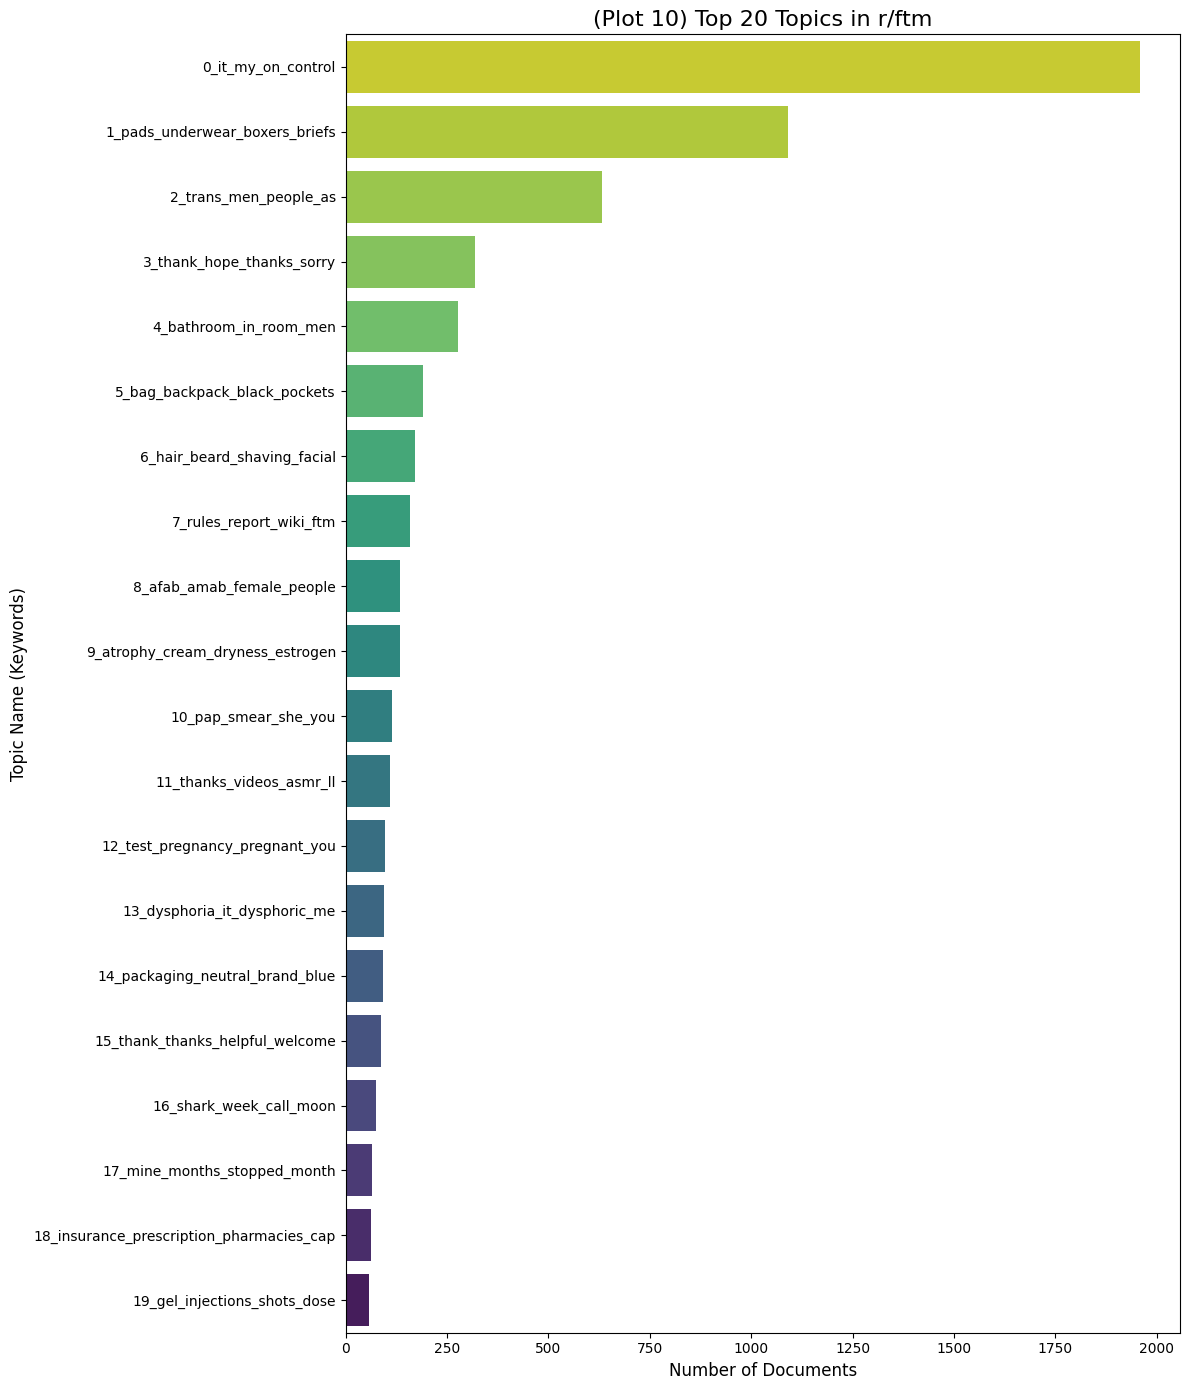

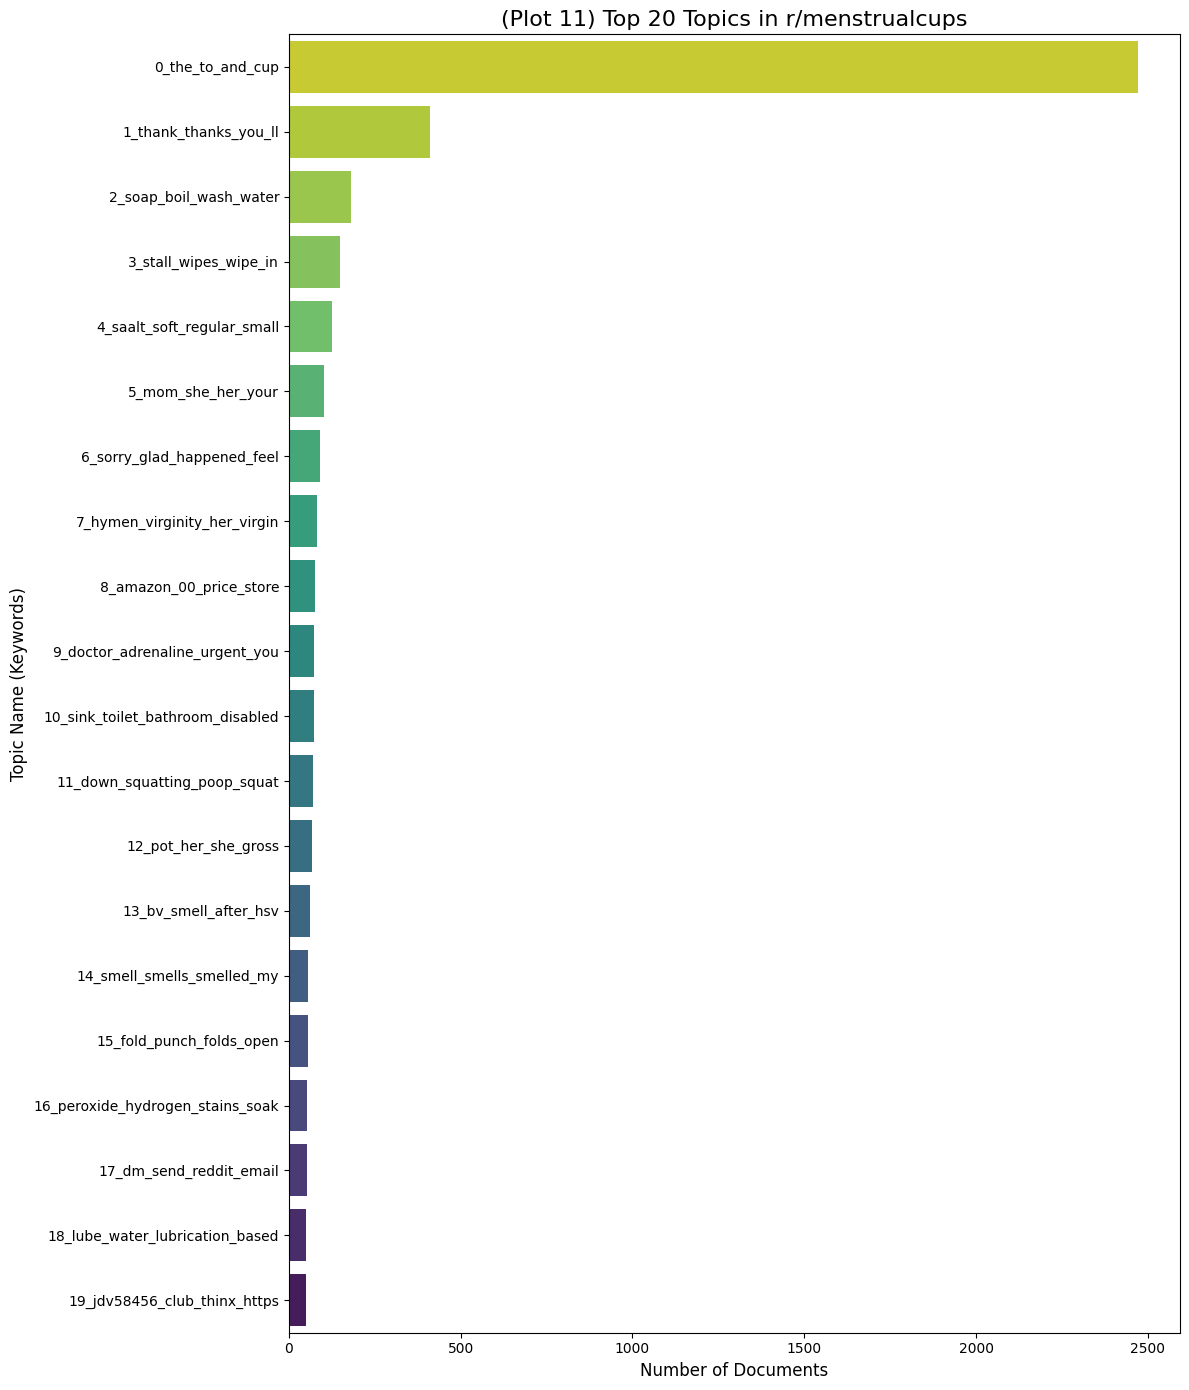

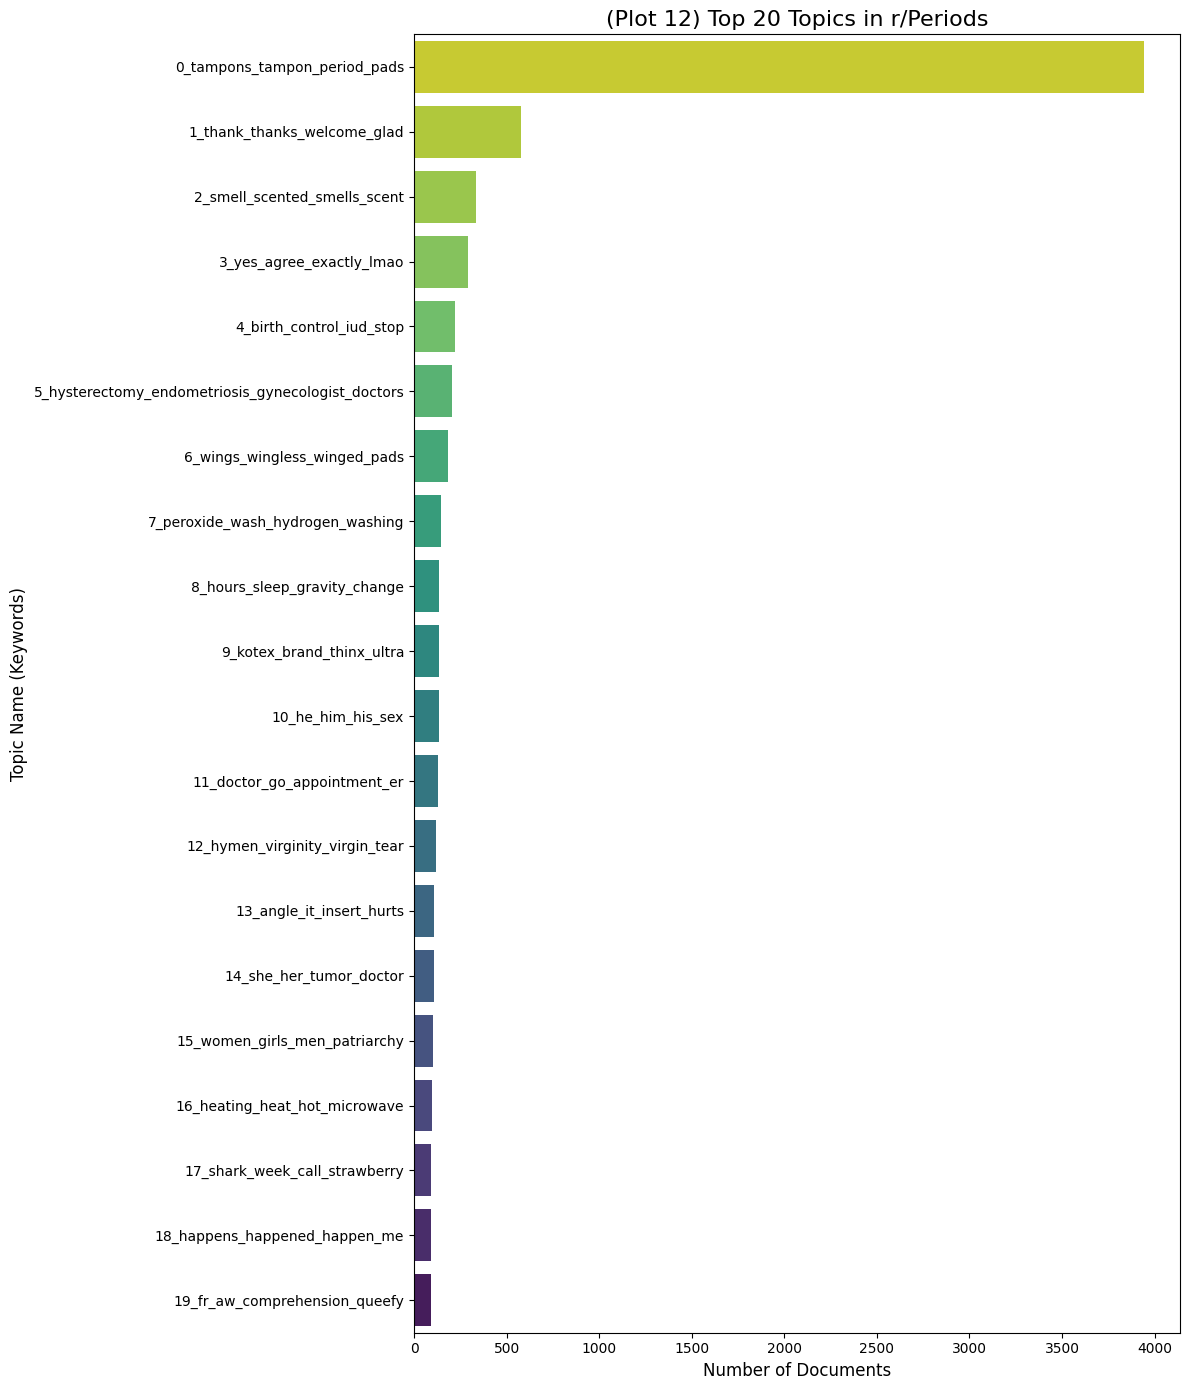

In [2]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

# Suppress all warnings for cleaner output
warnings.filterwarnings("ignore")

print("--- Phase 4b (FINAL): Comparative BERTopic Modeling ---")
print("Running for r/ftm, r/menstrualcups, AND r/Periods. Finding Top 20 topics.")

try:
    # --- 1. Load and Re-build Data (The "Super-Script" part) ---
    print("Loading original CSV files...")
    df_gender = pd.read_csv("gender_MASTER_clean.csv")
    df_products = pd.read_csv("products_MASTER_clean.csv")
    print("...Original files loaded.")
    
    # Add source and combine
    df_gender['source'] = 'gender'
    df_products['source'] = 'product'
    df = pd.concat([df_gender, df_products], ignore_index=True)
    
    # Create Text Column
    print("Creating 'text_to_analyze' column...")
    df['text_to_analyze'] = df['comment_body'].fillna(df['post_body'])
    df.dropna(subset=['text_to_analyze'], inplace=True)
    df['text_to_analyze'] = df['text_to_analyze'].astype(str)
    print(f"Created master DataFrame with {len(df)} documents.")

    # --- 2. Prepare the 3 Corpora ---
    # Corpus 1: Identity-Focused (r/ftm)
    corpus_ftm = df[df['subreddit'] == 'ftm']['text_to_analyze'].tolist()
    print(f"Created 'r/ftm' corpus with {len(corpus_ftm)} documents.")

    # Corpus 2: Product-Focused (r/menstrualcups)
    corpus_cups = df[df['subreddit'] == 'menstrualcups']['text_to_analyze'].tolist()
    print(f"Created 'r/menstrualcups' corpus with {len(corpus_cups)} documents.")
    
    # Corpus 3: General (r/Periods) - NEW
    corpus_periods = df[df['subreddit'] == 'Periods']['text_to_analyze'].tolist()
    print(f"Created 'r/Periods' corpus with {len(corpus_periods)} documents.")

    # --- 3. Define our modeling function ---
    def run_bertopic(corpus, corpus_name, plot_number):
        print(f"\n--- Starting BERTopic for {corpus_name} ---")
        
        # Load embedding model
        embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
        
        # Initialize BERTopic
        topic_model = BERTopic(
            embedding_model=embedding_model,
            nr_topics="auto",
            verbose=True
        )

        print(f"Fitting BERTopic model for {corpus_name}... (This will take a long time)")
        topics, probs = topic_model.fit_transform(corpus)

        print("...Fit complete.")
        
        # 4. Get Topic Data
        topic_info = topic_model.get_topic_info()
        
        # --- MODIFICATION: Get Top 20 topics ---
        real_topics = topic_info[topic_info.Topic != -1].head(20)
        
        print(f"\n--- Top 20 Topics for {corpus_name} ---")
        print(real_topics[['Name', 'Count']])

        # 5. Create "Normal" Bar Chart Visualization
        print("Generating standard bar chart...")
        # --- MODIFICATION: Make figure taller for 20 topics ---
        plt.figure(figsize=(12, 14)) 
        
        plot = sns.barplot(
            data=real_topics,
            x='Count',
            y='Name',
            palette='viridis_r'
        )
        
        # --- MODIFICATION: Change Title to "Top 20" ---
        plt.title(f'(Plot {plot_number}) Top 20 Topics in r/{corpus_name}', fontsize=16)
        plt.xlabel('Number of Documents', fontsize=12)
        plt.ylabel('Topic Name (Keywords)', fontsize=12)
        plt.yticks(fontsize=10)
        plt.tight_layout() # Make sure labels fit
        
        filename = f'plot_{plot_number}_top_20_topics_{corpus_name}.png'
        plt.savefig(filename, dpi=300)
        print(f"Saved '{filename}'")

        print(f"--- BERTopic for {corpus_name} COMPLETE ---")

    # --- 4. Run the models ---
    run_bertopic(corpus_ftm, "ftm", 10) 
    run_bertopic(corpus_cups, "menstrualcups", 11)
    run_bertopic(corpus_periods, "Periods", 12) # --- NEW ---

    print("\n--- Phase 4b (FINAL) Complete ---")
    print("Generated standard PNG bar charts for top 20 topics for all 3 communities.")

except FileNotFoundError:
    print("Error: Could not find 'gender_MASTER_clean.csv' or 'products_MASTER_clean.csv'.")
except ImportError:
    print("\n--- ERROR ---")
    print("BERTopic or sentence-transformers not installed.")
    print("Please run: pip install bertopic bertopic[visualization] sentence-transformers")
except Exception as e:
    print(f"An error occurred: {e}")

## 4.c LDA

--- Phase 4c (SUPER-SCRIPT): Re-building Data for LDA ---
Running without NLTK due to environment restrictions.
Loading original CSV files...
...Original files loaded.
Creating 'text_to_analyze' column...
Created master DataFrame with 100875 documents.
Created 'r/ftm' corpus with 13512 documents.
Created 'r/menstrualcups' corpus with 11488 documents.

--- Starting LDA for ftm ---
Preprocessing text...
Creating Document-Term Matrix...
Fitting LDA model...
Generating topic visualizations...
Saved 'plot_12_lda_topics_ftm.png'

--- Starting LDA for menstrualcups ---
Preprocessing text...
Creating Document-Term Matrix...
Fitting LDA model...
Generating topic visualizations...
Saved 'plot_13_lda_topics_menstrualcups.png'

--- Phase 4c (LDA) Complete ---
Generated standard PNG bar charts for LDA topics.


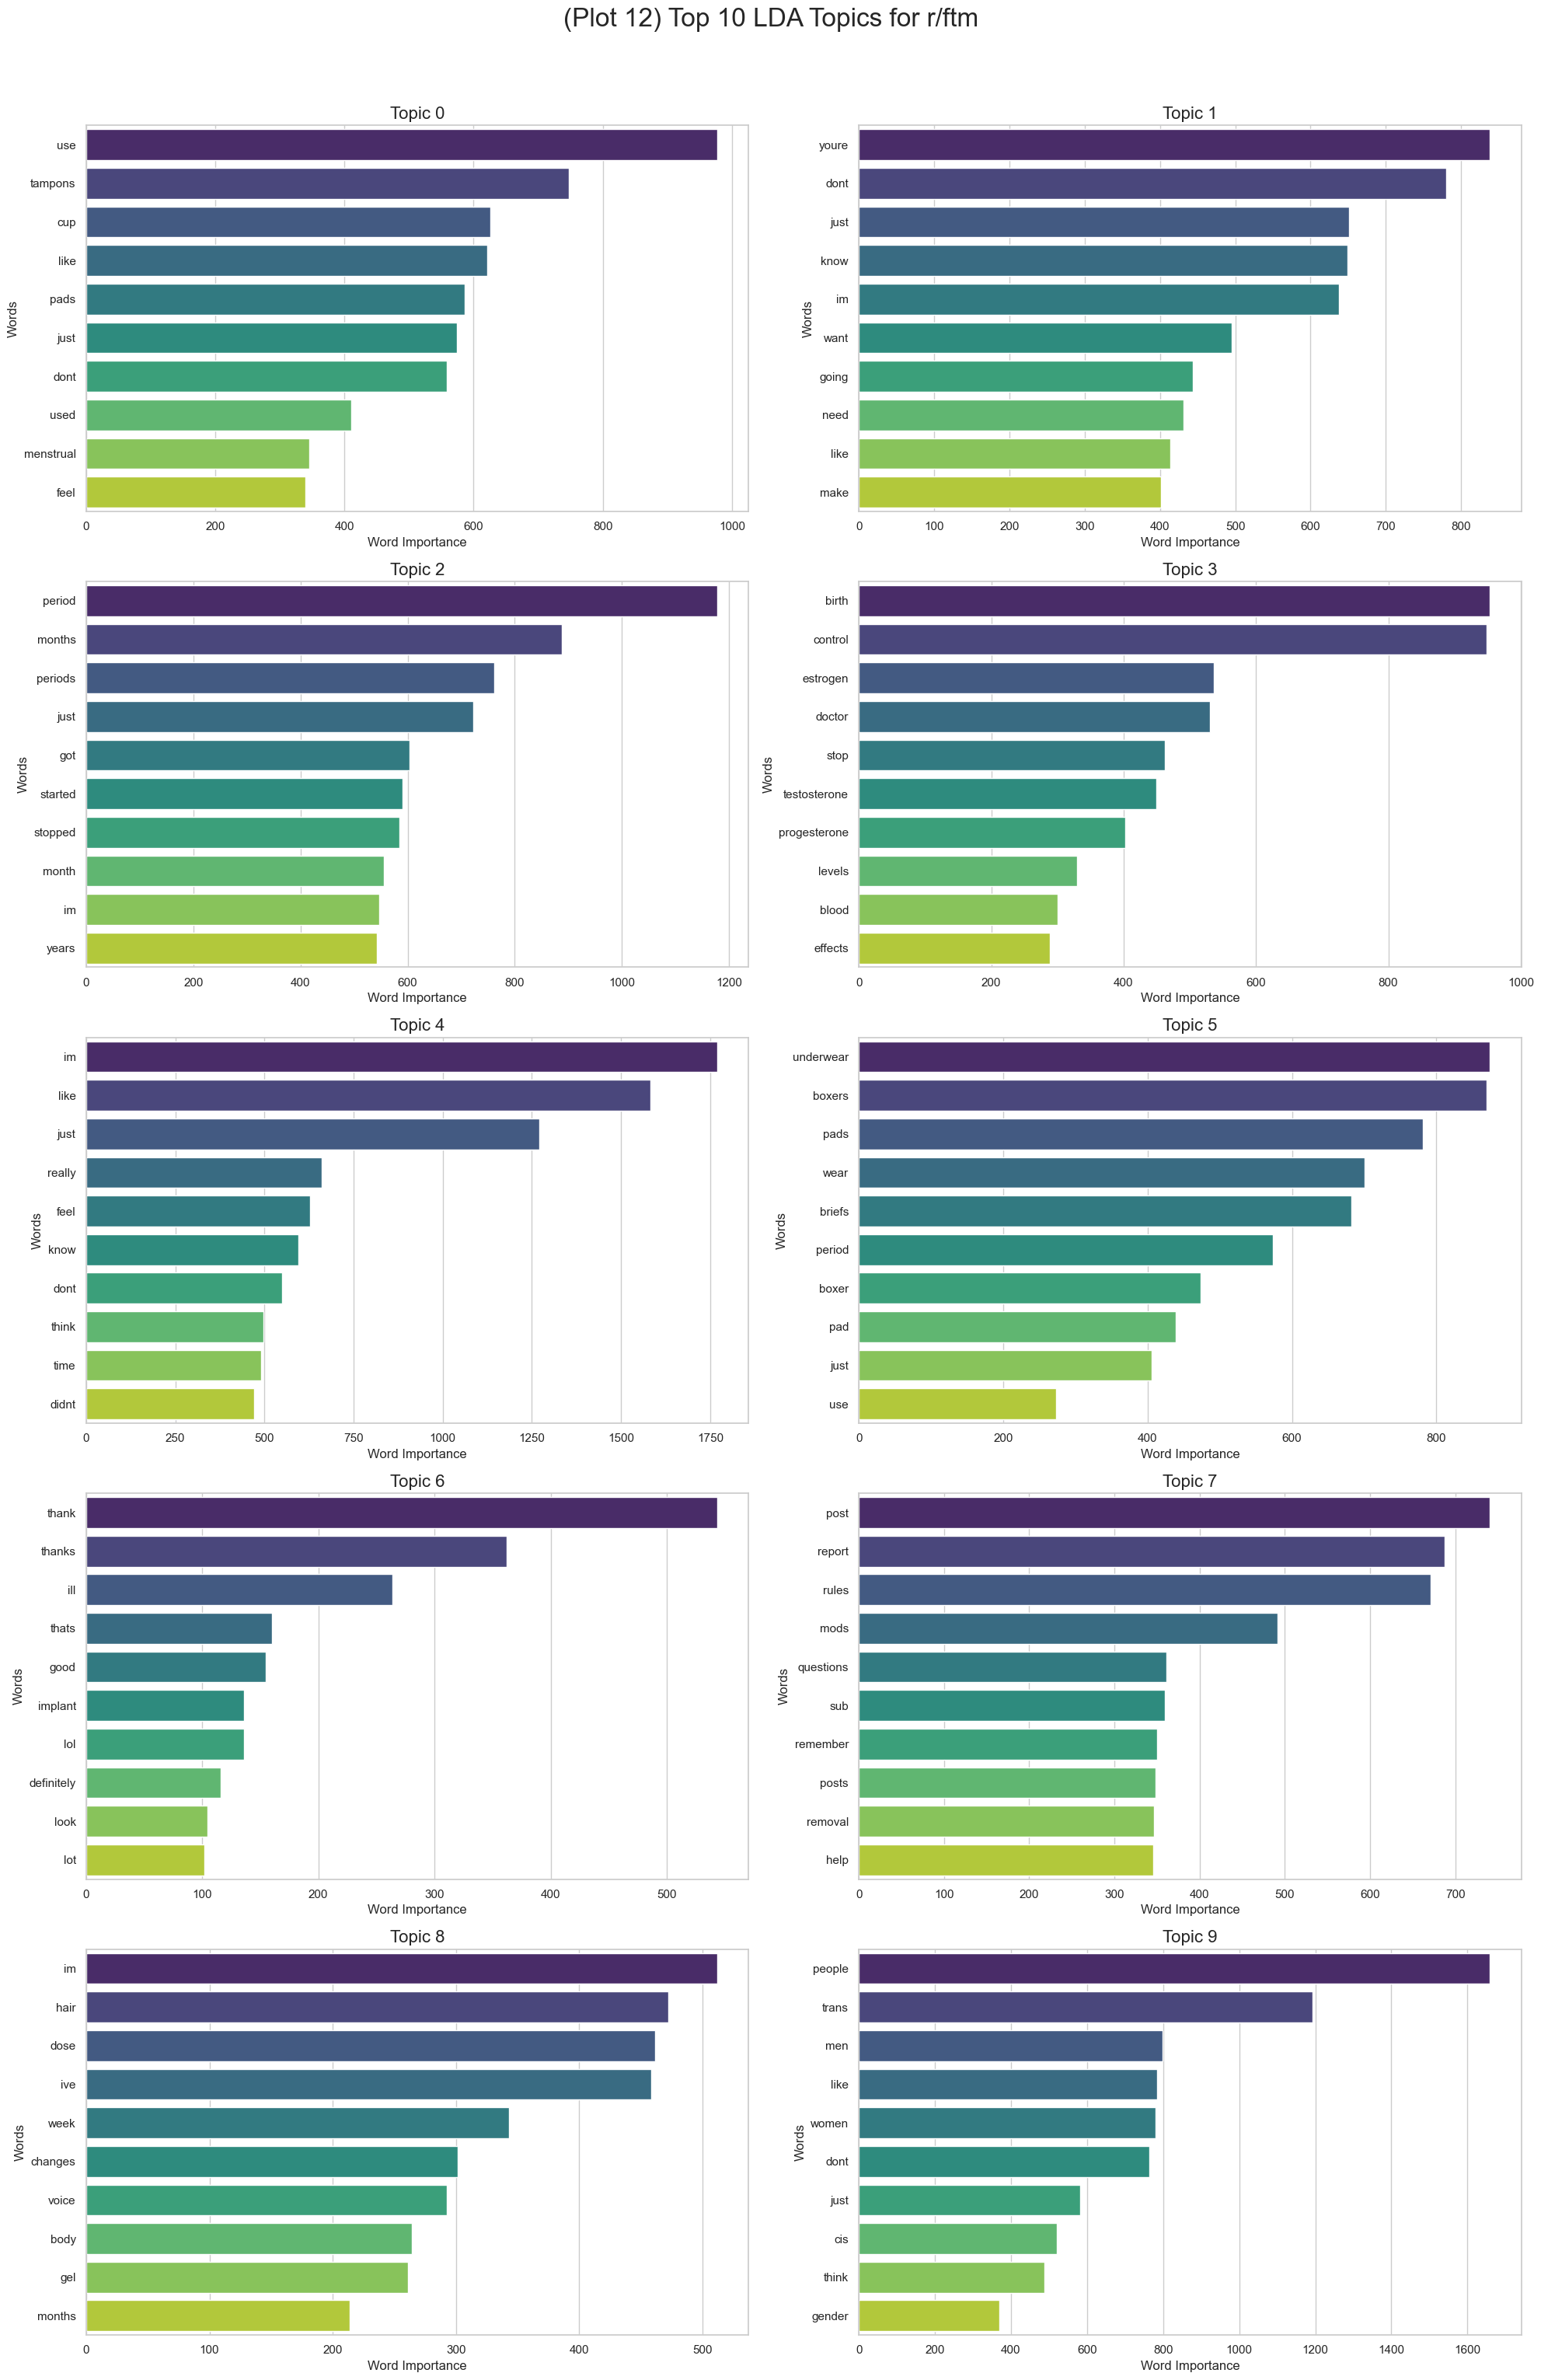

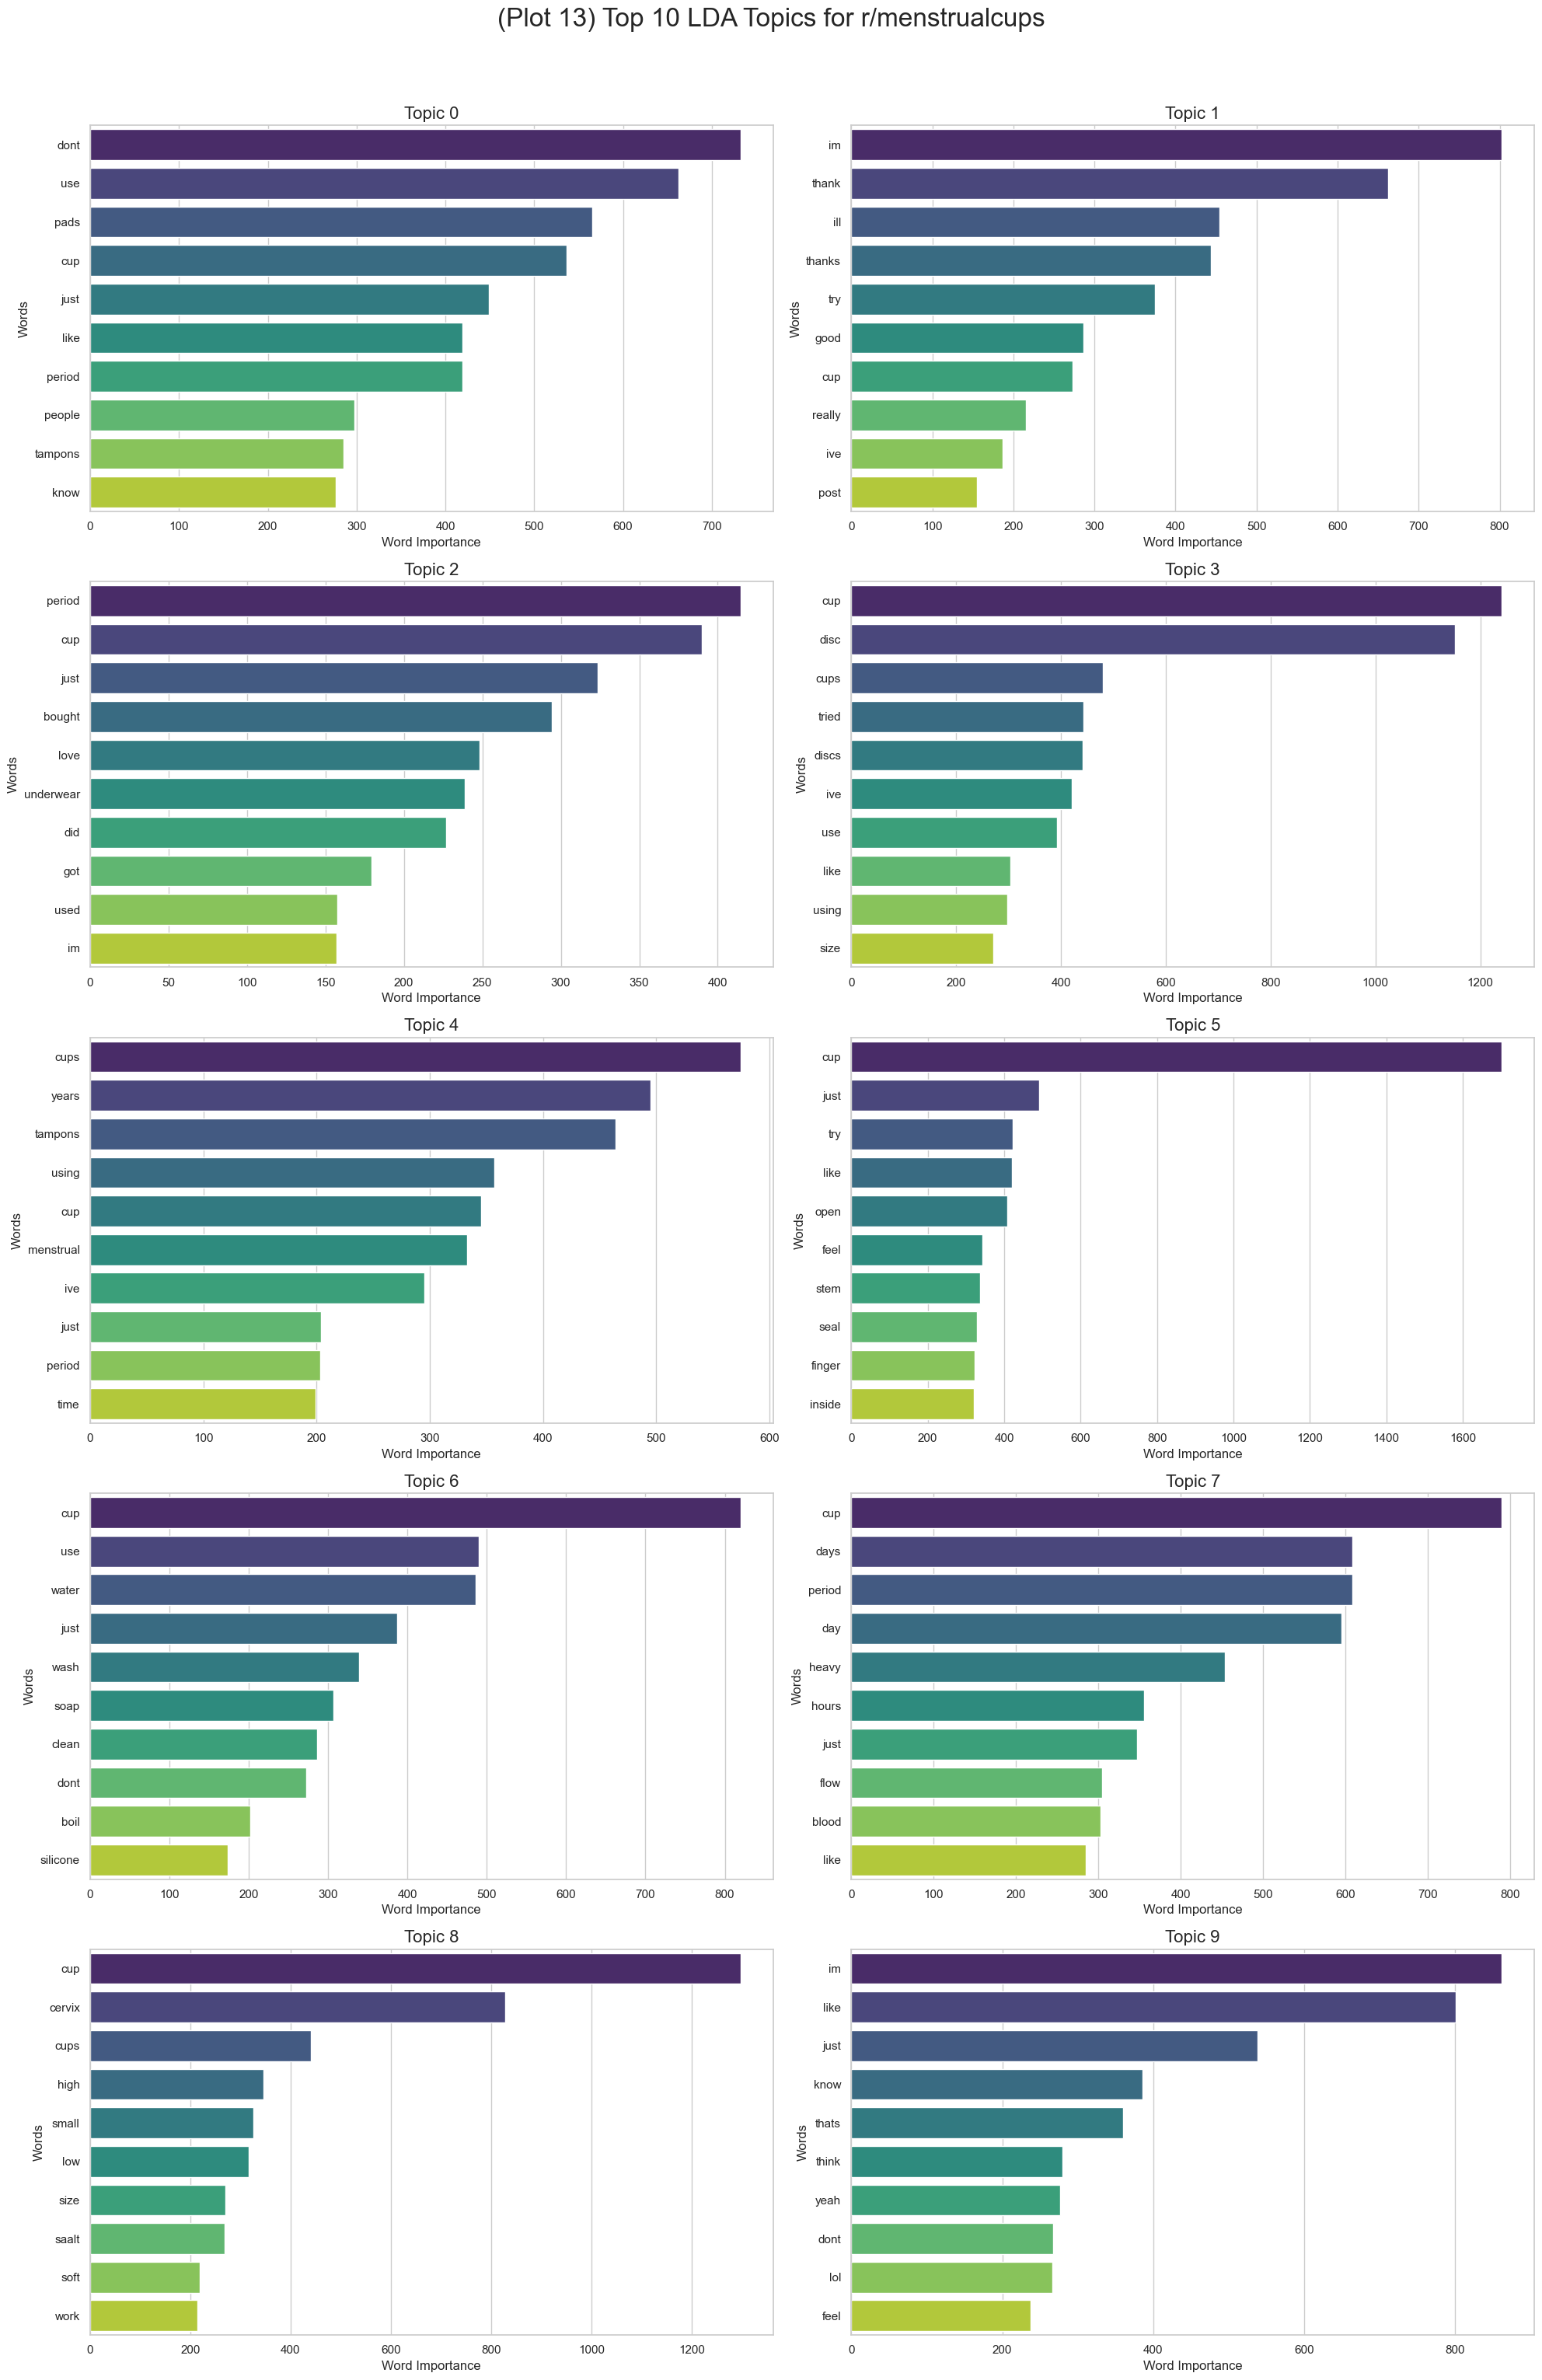

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import warnings

# Suppress all warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("--- Phase 4c (SUPER-SCRIPT): Re-building Data for LDA ---")
print("Running without NLTK due to environment restrictions.")

try:
    # --- 1. RE-RUN PHASE 1: Load and Combine Data ---
    print("Loading original CSV files...")
    df_gender = pd.read_csv("gender_MASTER_clean.csv")
    df_products = pd.read_csv("products_MASTER_clean.csv")
    print("...Original files loaded.")
    
    # Add source and combine
    df_gender['source'] = 'gender'
    df_products['source'] = 'product'
    master_df = pd.concat([df_gender, df_products], ignore_index=True)
    
    # --- 2. RE-RUN PHASE 2: Create Text Column ---
    print("Creating 'text_to_analyze' column...")
    # Prioritize comment_body, fallback to post_body
    master_df['text_to_analyze'] = master_df['comment_body'].fillna(master_df['post_body'])
    
    # Drop rows with no text
    master_df.dropna(subset=['text_to_analyze'], inplace=True)
    print(f"Created master DataFrame with {len(master_df)} documents.")

    # --- 3. Define Preprocessing Function (Simplified) ---
    def preprocess_text(text):
        if not isinstance(text, str):
            text = str(text)
        text = text.lower()
        # Remove punctuation, numbers, and keep only alphabetic words
        text = re.sub(r'[^a-zA-Z\s]', '', text, re.I|re.A)
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    # --- 4. Define LDA Modeling and Plotting Function ---
    def run_lda_and_plot(corpus, corpus_name, plot_prefix):
        """
        Takes a list of text documents and a name, runs LDA, and saves
        a PNG plot of the top topics.
        """
        print(f"\n--- Starting LDA for {corpus_name} ---")
        
        # Preprocess the text corpus
        print("Preprocessing text...")
        preprocessed_corpus = [preprocess_text(doc) for doc in corpus]
        
        # Create Document-Term Matrix (DTM)
        print("Creating Document-Term Matrix...")
        # Use scikit-learn's built-in stopword list
        vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=1000, stop_words='english')
        dtm = vectorizer.fit_transform(preprocessed_corpus)
        
        # Run LDA Model
        print("Fitting LDA model...")
        n_topics = 10 # We decided to find 10 topics
        lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
        lda.fit(dtm)
        
        # Get feature names
        feature_names = vectorizer.get_feature_names_out()
        
        # --- 5. Visualize Topics as Bar Charts ---
        print("Generating topic visualizations...")
        n_top_words = 10
        # Create a single figure with 10 subplots (5 rows, 2 columns)
        fig, axes = plt.subplots(5, 2, figsize=(20, 30), sharex=False)
        axes = axes.flatten() # Make it easy to iterate
        
        for topic_idx, topic in enumerate(lda.components_):
            # Get the top words for this topic
            top_words_indices = topic.argsort()[:-n_top_words - 1:-1]
            top_words = [feature_names[i] for i in top_words_indices]
            top_words_scores = topic[top_words_indices]
            
            # Create a bar plot
            ax = axes[topic_idx]
            sns.barplot(x=top_words_scores, y=np.array(top_words), ax=ax, palette="viridis")
            ax.set_title(f'Topic {topic_idx}', fontsize=16)
            ax.set_xlabel('Word Importance', fontsize=12)
            ax.set_ylabel('Words', fontsize=12)
            
        fig.suptitle(f'(Plot {plot_prefix}) Top 10 LDA Topics for r/{corpus_name}', fontsize=24, y=1.02)
        plt.tight_layout()
        
        # Save the combined plot as a single PNG
        filename = f'plot_{plot_prefix}_lda_topics_{corpus_name}.png'
        plt.savefig(filename, dpi=300)
        print(f"Saved '{filename}'")

    # --- 6. Extract Corpora and Run Models ---
    
    # Corpus 1: Identity-Focused (r/ftm)
    corpus_ftm = master_df[master_df['subreddit'] == 'ftm']['text_to_analyze'].tolist()
    print(f"Created 'r/ftm' corpus with {len(corpus_ftm)} documents.")

    # Corpus 2: Product-Focused (r/menstrualcups)
    corpus_cups = master_df[master_df['subreddit'] == 'menstrualcups']['text_to_analyze'].tolist()
    print(f"Created 'r/menstrualcups' corpus with {len(corpus_cups)} documents.")

    # Run the models for both corpora
    if corpus_ftm:
        run_lda_and_plot(corpus_ftm, "ftm", 12) # Creates plot_12...
    else:
        print("Skipping r/ftm: No documents found.")
        
    if corpus_cups:
        run_lda_and_plot(corpus_cups, "menstrualcups", 13) # Creates plot_13...
    else:
        print("Skipping r/menstrualcups: No documents found.")

    print("\n--- Phase 4c (LDA) Complete ---")
    print("Generated standard PNG bar charts for LDA topics.")

except FileNotFoundError as e:
    print(f"Error: {e}. Make sure 'gender_MASTER_clean.csv' and 'products_MASTER_clean.csv' are present.")
except Exception as e:
    print(f"An error occurred: {e}")